In [16]:
import pandas as pd
import numpy as np
import re


In [2]:
column_names = ['polarity','id','date','query','user','text']
dataset = pd.read_csv("/content/training.1600000.processed.noemoticon.csv",
                      encoding='latin-1',
                      header=None,
                      names=column_names,
                      skiprows=1)

print(dataset['polarity'].value_counts())
dataset['polarity'] = dataset['polarity'].replace(4, 1)
print(dataset['polarity'].value_counts())


polarity
0    799996
4    248576
Name: count, dtype: int64
polarity
0    799996
1    248576
Name: count, dtype: int64


In [17]:
def clean_text(text):
    if pd.isnull(text):   # Handle NaN values
        return ""
    text = str(text).lower()  # Ensure it's a string
    text = re.sub(r'https?://\S+|www\.\S+', '', text)  # Remove URLs
    text = re.sub(r'@\w+', '', text)  # Remove usernames
    text = re.sub(r'[^a-z\s]', '', text)  # Remove special chars & numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    return text

dataset['cleaned_text'] = dataset['text'].apply(clean_text)

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

In [19]:
X = dataset['cleaned_text']
y = dataset['polarity']

In [20]:
y = pd.to_numeric(y, errors="coerce")   # convert to numeric, invalid -> NaN
y = y.dropna().astype(int)
X = X.loc[y.index]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
vectorizer = TfidfVectorizer(max_features=5000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [22]:
model = LogisticRegression(max_iter=200)
model.fit(X_train_vec, y_train)

LogisticRegression(max_iter=200)

LogisticRegression(max_iter=200)

In [23]:
y_pred = model.predict(X_test_vec)
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8456762749445677
Accuracy: 0.8456762749445677


In [24]:
#SVM
from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, roc_auc_score

In [25]:
"""Trains and evaluates a Linear Support Vector Classifier.

This function initializes a LinearSVC model, fits it to the provided
training data, and then evaluates its performance on the test data.
It prints the model's accuracy and a detailed classification report
to the console.

Args:
    X_train_vec (array-like): The vectorized training features.
    y_train (array-like): The target labels for the training data.
    X_test_vec (array-like): The vectorized test features.
    y_test (array-like): The true target labels for the test data.

Returns:
    tuple: A tuple containing:
        - LinearSVC: The trained LinearSVC model object.
        - np.ndarray: The predictions made on the test data.
"""
svm_model = LinearSVC(max_iter=10000)
svm_model.fit(X_train_vec, y_train)

y_pred_svm = svm_model.predict(X_test_vec)
print("LinearSVC Accuracy:", accuracy_score(y_test, y_pred_svm))
print("SVM Report:\n", classification_report(y_test, y_pred_svm))

LinearSVC Accuracy: 0.8446939894618888
SVM Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90    160130
           1       0.75      0.51      0.61     49585

    accuracy                           0.84    209715
   macro avg       0.81      0.73      0.76    209715
weighted avg       0.84      0.84      0.83    209715

LinearSVC Accuracy: 0.8446939894618888
SVM Report:
               precision    recall  f1-score   support

           0       0.86      0.95      0.90    160130
           1       0.75      0.51      0.61     49585

    accuracy                           0.84    209715
   macro avg       0.81      0.73      0.76    209715
weighted avg       0.84      0.84      0.83    209715



In [26]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

"""Prepares raw text data for input into a Keras model.

This function performs two key preprocessing steps:
1.  Tokenization: It converts lists of text documents into sequences of
    integers, where each integer represents a unique word. A vocabulary is
    built based on the training data, limited by `max_words`.
2.  **Padding**: It ensures that all sequences have a uniform length (`max_len`)
    by truncating longer sequences or padding shorter ones.

Args:
    X_train (list of str): The list of training text samples.
    X_test (list of str): The list of testing text samples.
    max_words (int): The maximum number of most-frequent words to keep in
        the vocabulary.
    max_len (int): The uniform length for all output sequences after padding.

Returns:
    tuple: A tuple containing:
        - np.ndarray: The padded training sequences.
        - np.ndarray: The padded test sequences.
        - Tokenizer: The fitted tokenizer object, which contains the
          word-to-index mapping.
"""

max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

In [27]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from sklearn.metrics import accuracy_score, classification_report

"""Builds a Keras Sequential model for binary text classification.

This function constructs a neural network with an Embedding layer, a
selectable recurrent layer (RNN, LSTM, or GRU), a Dropout layer for
regularization, and a final Dense layer with a sigmoid activation
function for binary output. The model is compiled with the Adam
optimizer and binary cross-entropy loss.

Args:
    model_type (str, optional): The type of recurrent layer to use.
        Can be 'RNN', 'LSTM', or 'GRU'. Defaults to 'LSTM'.

Returns:
    tensorflow.keras.models.Sequential: The compiled, untrained Keras model.
"""

def build_rnn_model(model_type='LSTM'):
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=100, input_length=max_len))

    if model_type == 'RNN':
        model.add(SimpleRNN(128))
    elif model_type == 'LSTM':
        model.add(LSTM(128))
    elif model_type == 'GRU':
        model.add(GRU(128))

    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_rnn_model('LSTM')
lstm_model.fit(X_train_pad, y_train, epochs=2, batch_size=256, validation_split=0.1,verbose=1)

# Predict
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype("int32")

# Evaluation
print("LSTM Accuracy:", accuracy_score(y_test, y_pred_lstm))
print(classification_report(y_test, y_pred_lstm))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/2
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 1990s 674ms/step - accuracy: 0.8343 - loss: 0.3860 - val_accuracy: 0.8581 - val_loss: 0.3330
Epoch 2/2
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 1929s 649ms/step - accuracy: 0.8681 - loss: 0.3126 - val_accuracy: 0.8632 - val_loss: 0.3226
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 364s 55ms/step
LSTM Accuracy: 0.8638676298786448
              precision    recall  f1-score   support

           0       0.88      0.95      0.91    160130
           1       0.78      0.59      0.67     49585

    accuracy                           0.86    209715
   macro avg       0.83      0.77      0.79    209715
weighted avg       0.86      0.86      0.86    209715



/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/2
1779/2950 ━━━━━━━━━━━━━━━━━━━━ 12:05 619ms/step - accuracy: 0.8266 - loss: 0.4018

KeyboardInterrupt: 

In [ ]:
"""Builds a simple and fast Keras RNN model for binary classification.

This function constructs a lightweight Sequential model designed for
speed. The architecture consists of:
1. An Embedding layer to create dense vector representations of words.
2. A single SimpleRNN layer to process the sequence.
3. A Dropout layer to prevent overfitting.
4. A final Dense output layer with a sigmoid activation for binary
   (0 or 1) output.

The model is compiled using the 'adam' optimizer and 'binary_crossentropy'
loss, suitable for binary classification tasks.

Note: This function relies on globally defined `max_words` and `max_len`
variables. For better reusability, consider passing them as arguments.

Returns:
    tensorflow.keras.models.Sequential: The compiled, untrained Keras model.
"""
def build_fast_rnn():
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=50, input_length=max_len))
    model.add(SimpleRNN(64, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build and train
rnn_model = build_fast_rnn()
rnn_model.fit(X_train_pad, y_train, epochs=2, batch_size=256, validation_split=0.1, verbose=1)

# Predict
y_pred_rnn = (rnn_model.predict(X_test_pad) > 0.5).astype("int32")

# Evaluation
print("RNN Accuracy:", accuracy_score(y_test, y_pred_rnn))
print(classification_report(y_test, y_pred_rnn))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/2
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 248s 83ms/step - accuracy: 0.8206 - loss: 0.4119 - val_accuracy: 0.8518 - val_loss: 0.3515
Epoch 2/2
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 242s 82ms/step - accuracy: 0.8589 - loss: 0.3369 - val_accuracy: 0.8542 - val_loss: 0.3444
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 54s 8ms/step
RNN Accuracy: 0.8545645280499726
              precision    recall  f1-score   support

           0       0.87      0.95      0.91    160130
           1       0.78      0.54      0.64     49585

    accuracy                           0.85    209715
   macro avg       0.82      0.75      0.77    209715
weighted avg       0.85      0.85      0.84    209715



In [ ]:
"""Builds a Keras Sequential model with a GRU layer for binary classification.

This function constructs a lightweight neural network optimized for speed and
efficiency in text classification tasks. The architecture includes:
1. An Embedding layer to convert word indices into dense vectors.
2. A GRU (Gated Recurrent Unit) layer to process the sequence data.
3. A Dropout layer for regularization to help prevent overfitting.
4. A final Dense layer with a sigmoid activation function for binary
   (0 or 1) output.

The model is compiled with the 'adam' optimizer and 'binary_crossentropy'
loss, making it suitable for binary classification problems.

Note: This function relies on globally defined `max_words` and `max_len`
variables. For better reusability, it is recommended to pass these
as arguments.

Returns:
    tensorflow.keras.models.Sequential: The compiled, untrained Keras model.
"""
def build_fast_gru():
    model = Sequential()
    model.add(Embedding(input_dim=max_words, output_dim=50, input_length=max_len))
    model.add(GRU(64, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Build and train
gru_model = build_fast_gru()
gru_model.fit(X_train_pad, y_train, epochs=2, batch_size=256, validation_split=0.1, verbose=1)

# Predict
y_pred_gru = (gru_model.predict(X_test_pad) > 0.5).astype("int32")

# Evaluation
print("GRU Accuracy:", accuracy_score(y_test, y_pred_gru))
print(classification_report(y_test, y_pred_gru))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/2
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 982s 332ms/step - accuracy: 0.8318 - loss: 0.3898 - val_accuracy: 0.8570 - val_loss: 0.3350
Epoch 2/2
2950/2950 ━━━━━━━━━━━━━━━━━━━━ 982s 332ms/step - accuracy: 0.8658 - loss: 0.3196 - val_accuracy: 0.8603 - val_loss: 0.3273
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 134s 20ms/step
GRU Accuracy: 0.861855375151992
              precision    recall  f1-score   support

           0       0.88      0.94      0.91    160130
           1       0.77      0.60      0.67     49585

    accuracy                           0.86    209715
   macro avg       0.82      0.77      0.79    209715
weighted avg       0.86      0.86      0.86    209715



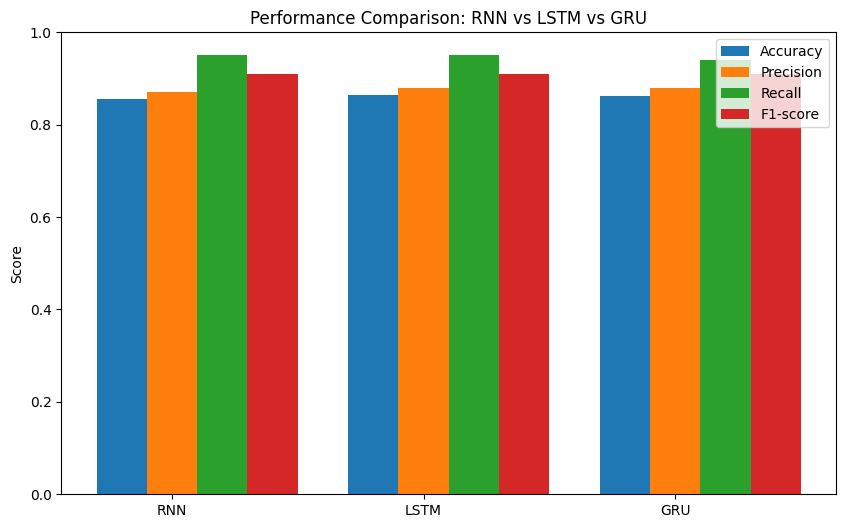

In [30]:
import matplotlib.pyplot as plt
import numpy as np

metrics = {
    "RNN":     {"Accuracy": 0.8545645280499726, "Precision": 0.87, "Recall": 0.95, "F1-score": 0.91},
    "LSTM":    {"Accuracy": 0.8638676298786448, "Precision": 0.88, "Recall": 0.95, "F1-score": 0.91},
    "GRU":     {"Accuracy": 0.861855375151992, "Precision": 0.88 , "Recall": 0.94, "F1-score": 0.91},
}

# Extract metrics
models = list(metrics.keys())
metric_names = list(next(iter(metrics.values())).keys())

# Plot each metric
x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

for i, metric in enumerate(metric_names):
    values = [metrics[m][metric] for m in models]
    plt.bar(x + i*width, values, width, label=metric)

# Styling
plt.xticks(x + width, models)
plt.ylim(0, 1)
plt.ylabel("Score")
plt.title("Performance Comparison: RNN vs LSTM vs GRU")
plt.legend()
plt.show()


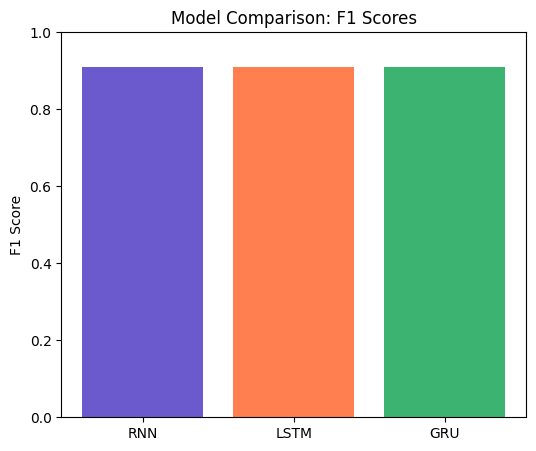

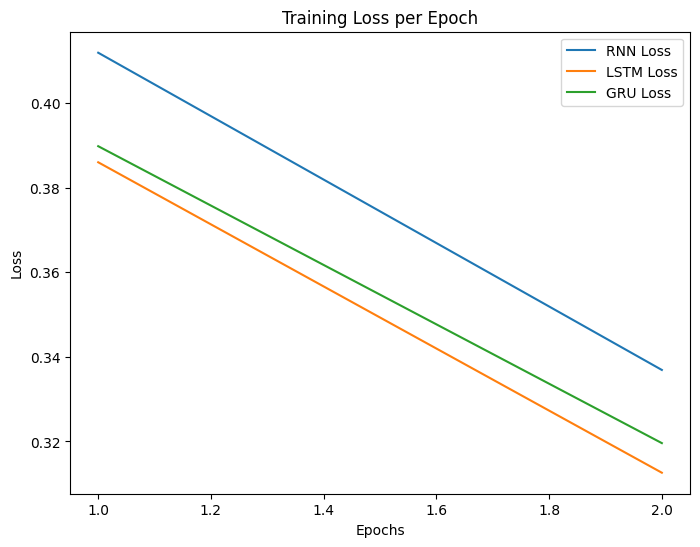

6554/6554 ━━━━━━━━━━━━━━━━━━━━ 64s 10ms/step
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 422s 64ms/step
6554/6554 ━━━━━━━━━━━━━━━━━━━━ 109s 17ms/step


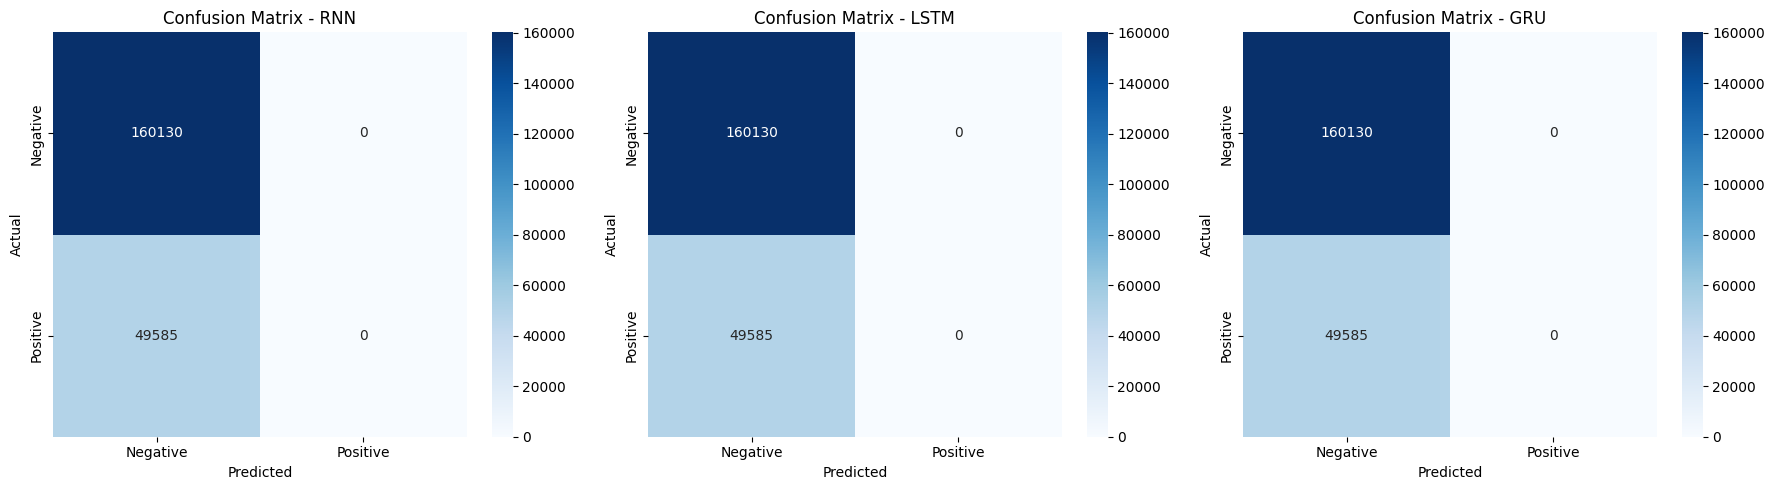

In [47]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np


"""
Model Performance Visualization and Comparison Script.

This script visualizes and compares the performance of three pre-trained
Recurrent Neural Network models: a simple RNN, an LSTM, and a GRU.

The script performs the following three main actions:
1.  F1 Score Comparison: Generates a bar chart to compare the F1 scores
    of the models based on a predefined metrics dictionary.
2.  Training Loss Plot: Creates a line graph to visualize and compare
    the training loss of each model over the training epochs.
3.  Confusion Matrix Visualization: Calculates and displays the
    confusion matrix for each model's predictions on the test set,
    presenting them side-by-side for easy comparison.

Assumptions:
    - The models (`rnn_model`, `lstm_model`, `gru_model`) are pre-trained
      and available in the environment.
    - The test data (`X_test`, `y_test`) and training data (`X_train`)
      are loaded and available.
"""
metrics = {
    "RNN":     {"Accuracy": 0.8545645280499726, "Precision": 0.87, "Recall": 0.95, "F1-score": 0.91},
    "LSTM":    {"Accuracy": 0.8638676298786448, "Precision": 0.88, "Recall": 0.95, "F1-score": 0.91},
    "GRU":     {"Accuracy": 0.861855375151992, "Precision": 0.88 , "Recall": 0.94, "F1-score": 0.91},
}

# Bar Graph
plt.figure(figsize=(6,5))
model_names = list(metrics.keys())
f1_scores = [metrics[m]["F1-score"] for m in model_names]
plt.bar(model_names, f1_scores, color=["#6A5ACD","#FF7F50","#3CB371"])
plt.title("Model Comparison: F1 Scores")
plt.ylabel("F1 Score")
plt.ylim(0,1)
plt.show()


epochs = range(1, 3)
gru_loss = [0.3898, 0.3196]
lstm_loss = [0.3860, 0.3126]
rnn_loss = [ 0.4119, 0.3369]

plt.figure(figsize=(8,6))
plt.plot(epochs, rnn_loss, label="RNN Loss")
plt.plot(epochs, lstm_loss, label="LSTM Loss")
plt.plot(epochs, gru_loss, label="GRU Loss")
plt.title("Training Loss per Epoch")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


keras_tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
keras_tokenizer.fit_on_texts(X_train)

X_test_seq = keras_tokenizer.texts_to_sequences(X_test)
X_test_pad = pad_sequences(X_test_seq, maxlen=100, padding='post')


y_pred_rnn = (rnn_model.predict(X_test_pad) > 0.5).astype(int)
y_pred_lstm = (lstm_model.predict(X_test_pad) > 0.5).astype(int)
y_pred_gru = (gru_model.predict(X_test_pad) > 0.5).astype(int)

cm_rnn = confusion_matrix(y_test, y_pred_rnn)
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
cm_gru = confusion_matrix(y_test, y_pred_gru)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm, title in zip(
    axes,
    [cm_rnn, cm_lstm, cm_gru],
    ["RNN", "LSTM", "GRU"]
):
    sns.heatmap(cm, annot=True, fmt='d', cmap="Blues",
                xticklabels=["Negative", "Positive"],
                yticklabels=["Negative", "Positive"],
                ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {title}")

plt.tight_layout()
plt.show()

In [16]:
!pip install transformers datasets torch -q

import pandas as pd
import torch
from torch.utils.data import DataLoader, TensorDataset
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from tqdm import tqdm

In [17]:
"""
Fine-tunes a pre-trained DistilBERT model for binary sentiment classification.

This script performs a complete machine learning workflow:
1.  Data Loading & Preprocessing: Loads the sentiment140 dataset, samples
    a smaller subset for efficiency, cleans it by selecting relevant columns,
    and maps the sentiment labels to a binary format (0 for negative, 1 for
    positive).
2.  Tokenization: Uses the DistilBertTokenizerFast to convert the text data
    into numerical tokens that the model can understand.
3.  Dataset Preparation: Creates PyTorch TensorDatasets and DataLoaders to
    handle the data in batches efficiently during training and evaluation.
4.  Model Initialization: Loads a pre-trained DistilBERT model configured
    for sequence classification and sets up the AdamW optimizer and cross-entropy
    loss function.
5.  Training: Fine-tunes the model on the training dataset for a specified
    number of epochs, updating the model's weights to learn the sentiment
    classification task. A progress bar from tqdm is used to monitor training.
6.  Evaluation: Evaluates the performance of the fine-tuned model on the
    unseen test dataset and prints key classification metrics, including
    accuracy, precision, recall, and the F1-score.
"""
# Load dataset
file_path = "/content/training.1600000.processed.noemoticon.csv"
df = pd.read_csv(file_path, encoding="latin-1", header=None)
df = df.sample(50000, random_state=42)
df = df[[0, 5]]
df.columns = ["label", "text"]
df["label"] = df["label"].apply(lambda x: 0 if x == 0 else 1)

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"], df["label"], test_size=0.2, random_state=42
)


#Tokenizer
tokenizer = DistilBertTokenizerFast.from_pretrained("distilbert-base-uncased")
train_encodings = tokenizer(list(train_texts), truncation=True, padding=True, max_length=128, return_tensors="pt")
test_encodings  = tokenizer(list(test_texts), truncation=True, padding=True, max_length=128, return_tensors="pt")

train_labels = torch.tensor(train_labels.tolist())
test_labels  = torch.tensor(test_labels.tolist())

train_dataset = TensorDataset(train_encodings['input_ids'], train_encodings['attention_mask'], train_labels)
test_dataset  = TensorDataset(test_encodings['input_ids'], test_encodings['attention_mask'], test_labels)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)


#Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=2)
model.to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
loss_fn = torch.nn.CrossEntropyLoss()


#Training
epochs = 2
for epoch in range(epochs):
    model.train()
    loop = tqdm(train_loader, leave=True)
    for batch in loop:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask=attention_mask)
        loss = loss_fn(outputs.logits, labels)
        loss.backward()
        optimizer.step()
        loop.set_description(f"Epoch {epoch+1}")


#Evaluation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, labels = [b.to(device) for b in batch]
        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')

print(f"\nTest Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}, Recall: {recall:.4f}, F1-score: {f1:.4f}")


/tmp/ipython-input-1144819367.py:5: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(file_path, encoding="latin-1", header=None)
Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Epoch 2: 100%|██████████| 2500/2500 [07:10<00:00,  5.81it/s]



Test Accuracy: 0.7538
Precision: 0.7303, Recall: 0.5267, F1-score: 0.6120
